In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
cd drive/MyDrive/UCI/178/project/

/content/drive/MyDrive/UCI/178/project


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("training_data.csv")
df.head()

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,83148,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,1,MC,?,34,0,10,6,0,0,490,427,571,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
1,8067,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,2,?,Family/GeneralPractice,39,0,11,0,0,0,428,250,305,4,NaN,NaN,Steady,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
2,19623,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,5,?,Family/GeneralPractice,63,1,11,1,0,11,535,285,585,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30
3,77236,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,2,MC,?,39,0,22,3,0,2,482,428,585,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
4,55677,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,12,?,InternalMedicine,71,1,15,0,0,0,733,584,682,6,Norm,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0


In [6]:
"""
Imputing with NaN to get True NaN missing value counts

"""
missing_cols = ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'gender']

column_to_missing = {}
for col in missing_cols:
    if col != 'gender':
        column_to_missing[col] = '?'
    else:
        column_to_missing[col] = 'Unknown/Invalid'

print(column_to_missing)

{'race': '?', 'weight': '?', 'payer_code': '?', 'medical_specialty': '?', 'diag_1': '?', 'diag_2': '?', 'diag_3': '?', 'gender': 'Unknown/Invalid'}


In [7]:
df_1 = df.copy()
for col, miss_val in column_to_missing.items():
    df_1[col] = df_1[col].replace(miss_val, np.nan)
message = "True Missing Counts:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().sum()

True Missing Counts:


,0
Unnamed: 0,0
encounter_id,0
patient_nbr,0
race,2044
gender,2
age,0
weight,88727
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0


In [8]:
message = "Percentage of Missing Values:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().mean().round(4)*100

Percentage of Missing Values:


,0
Unnamed: 0,0.00
encounter_id,0.00
patient_nbr,0.00
race,2.23
gender,0.00
age,0.00
weight,96.88
admission_type_id,0.00
discharge_disposition_id,0.00
admission_source_id,0.00


In [9]:
df_1_non_numeric = df_1.select_dtypes(exclude='number')
for col in df_1_non_numeric.columns.values:
    print(f"{col}: ", df_1[col].unique(), end='\n\n')

race:  ['Caucasian' 'AfricanAmerican' 'Hispanic' nan 'Other' 'Asian']

gender:  ['Female' 'Male' nan]

age:  ['[60-70)' '[40-50)' '[70-80)' '[80-90)' '[50-60)' '[30-40)' '[20-30)'
 '[90-100)' '[10-20)' '[0-10)']

weight:  [nan '[75-100)' '[100-125)' '[50-75)' '[125-150)' '[25-50)' '[0-25)'
 '[150-175)' '[175-200)' '>200']

payer_code:  ['MC' nan 'BC' 'CM' 'SP' 'HM' 'OG' 'MD' 'UN' 'CP' 'OT' 'PO' 'DM' 'WC' 'SI'
 'CH' 'MP' 'FR']

medical_specialty:  [nan 'Family/GeneralPractice' 'InternalMedicine' 'Cardiology'
 'Surgery-General' 'Surgery-Vascular' 'Urology' 'Emergency/Trauma'
 'Surgery-Neuro' 'Orthopedics-Reconstructive'
 'PhysicalMedicineandRehabilitation' 'Surgery-Cardiovascular/Thoracic'
 'ObstetricsandGynecology' 'Gastroenterology' 'Orthopedics'
 'Surgery-Plastic' 'Podiatry' 'Surgery-Thoracic' 'Nephrology' 'Psychiatry'
 'Radiologist' 'Pulmonology' 'Pediatrics-CriticalCare' 'Psychology'
 'Pediatrics-Endocrinology' 'Neurology' 'Hematology/Oncology' 'Pediatrics'
 'OutreachServices' 'Surg

In [10]:
"""
Diagnosis Groups:

Grouping based on ICD9 Grouping (source: Wikipedia)
"""
diags_ICD9_dict = {
    '001–139': 'infectious and parasitic diseases',
    '140–239': 'neoplasms',
    '240–279': 'endocrine, nutritional and metabolic diseases, and immunity disorders',
    '280–289': 'diseases of the blood and blood-forming organs',
    '290–319': 'mental disorders',
    '320–389': 'diseases of the nervous system and sense organs',
    '390–459': 'diseases of the circulatory system',
    '460–519': 'diseases of the respiratory system',
    '520–579': 'diseases of the digestive system',
    '580–629': 'diseases of the genitourinary system',
    '630–679': 'complications of pregnancy, childbirth, and the puerperium',
    '680–709': 'diseases of the skin and subcutaneous tissue',
    '710–739': 'diseases of the musculoskeletal system and connective tissue',
    '740–759': 'congenital anomalies',
    '760–779': 'certain conditions originating in the perinatal period',
    '780–799': 'symptoms, signs, and ill-defined conditions',
    '800–999': 'injury and poisoning',
    'E & V codes': 'external causes of injury and supplemental classification',
}

def categorize_diag(code: str) -> str:
    code_float = float(code)
    code_int = int(code_float)
    if code_int >= 800:
        return '800–999'
    elif code_int >= 780:
        return '780–799'
    elif code_int >= 760:
        return '760–779'
    elif code_int >= 740:
        return '740–759'
    elif code_int >= 710:
        return '710–739'
    elif code_int >= 680:
        return '680–709'
    elif code_int >= 630:
        return '630–679'
    elif code_int >= 580:
        return '580–629'
    elif code_int >= 520:
        return '520–579'
    elif code_int >= 460:
        return '460–519'
    elif code_int >= 390:
        return '390–459'
    elif code_int >= 320:
        return '320–389'
    elif code_int >= 290:
        return '290–319'
    elif code_int >= 280:
        return '280–289'
    elif code_int >= 240:
        return '240–279'
    elif code_int >= 140:
        return '140–239'
    else:
        return '001–139'

def convert_EV_code(code: str) -> str:
    return 'E & V codes'


"""
Medical Specialty Groups:

Grouping based on Google Gemini output
"""

specialty_mapping = {
    'PrimaryCare': [
        'Family/GeneralPractice', 'InternalMedicine', 'Hospitalist',
        'Osteopath', 'Resident'
    ],
    'Surgery': [
        'Surgery-General', 'Surgery-Vascular', 'Urology', 'Surgery-Neuro',
        'Orthopedics-Reconstructive', 'Surgery-Cardiovascular/Thoracic',
        'Orthopedics', 'Surgery-Plastic', 'Podiatry', 'Surgery-Thoracic',
        'Surgery-Colon&Rectal', 'Otolaryngology', 'Surgery-Cardiovascular',
        'Surgeon', 'Proctology', 'Surgery-Maxillofacial', 'SurgicalSpecialty',
        'Dentistry', 'Ophthalmology', 'Surgery-PlasticwithinHeadandNeck'
    ],
    'InternalMedicine_Subspecialty': [
        'Cardiology', 'Gastroenterology', 'Nephrology', 'Pulmonology',
        'Neurology', 'Hematology/Oncology', 'Endocrinology-Metabolism',
        'Hematology', 'Oncology', 'Endocrinology', 'InfectiousDiseases',
        'Rheumatology', 'AllergyandImmunology', 'Neurophysiology', 'Dermatology'
    ],
    'Emergency_CriticalCare': [
        'Emergency/Trauma'
    ],
    'Maternal_Pediatric': [
        'ObstetricsandGynecology', 'Pediatrics-CriticalCare', 'Pediatrics-Endocrinology',
        'Pediatrics', 'Gynecology', 'Pediatrics-Pulmonology', 'Pediatrics-Neurology',
        'Obsterics&Gynecology-GynecologicOnco', 'Pediatrics-AllergyandImmunology',
        'Cardiology-Pediatric', 'Anesthesiology-Pediatric', 'Obstetrics',
        'Surgery-Pediatric', 'Perinatology', 'Pediatrics-EmergencyMedicine',
        'Pediatrics-Hematology-Oncology', 'Psychiatry-Child/Adolescent',
        'Pediatrics-InfectiousDiseases'
    ],
    'Psych_Rehab_Support': [
        'PhysicalMedicineandRehabilitation', 'Psychiatry', 'Psychology',
        'Anesthesiology', 'Speech', 'SportsMedicine'
    ],
    'Diagnostics_Other': [
        'Radiologist', 'Radiology', 'Pathology', 'OutreachServices', 'DCPTEAM'
    ],
    'Missing': [
        'PhysicianNotFound'
    ]
}

def map_specialty_to_group(specialty):
    if pd.isna(specialty):
        return specialty
    for key, value in specialty_mapping.items():
        if specialty in value:
            return key
    return 'Other'

---
## Starting Feature Transformations & Imputation

In [11]:
"""
Grouping Transformations (4 total)

2 types: diagnosis and medical specialty
"""

"""
Categorizing diagnoses codes into diagnosis groups => reduces features.

Applies to: `diag_1`, `diag_2`, & `diag_3`
"""
df_2 = df_1.copy()
for i in range(1,4):

    mask = df_2[f'diag_{i}'].str.contains('^[EV]', regex=True, na=False)
    mask_nan = df_2[f'diag_{i}'].isna()
    combined_mask = mask | mask_nan

    df_2.loc[~combined_mask, f'diag_{i}'] = df_2.loc[~combined_mask, f'diag_{i}'].apply(categorize_diag)
    df_2.loc[mask, f'diag_{i}'] = df_2.loc[mask, f'diag_{i}'].apply(convert_EV_code)
    print(f"diag_{i}: ", df_2[f'diag_{i}'].unique(), end='\n\n')

"""
Based on medical specialty => reduces total features

Applies to: `medical_specialty`
"""
df_2['medical_specialty'] = df_2['medical_specialty'].apply(map_specialty_to_group)
df_2['medical_specialty'].unique()

diag_1:  ['460–519' '390–459' '520–579' '710–739' '800–999' '780–799' '290–319'
 '140–239' '240–279' '580–629' '001–139' 'E & V codes' '630–679' '680–709'
 '280–289' '320–389' nan '740–759']

diag_2:  ['390–459' '240–279' '280–289' '580–629' 'E & V codes' '780–799' '460–519'
 '320–389' '520–579' '290–319' '680–709' '001–139' '800–999' '710–739'
 '140–239' '630–679' nan '740–759']

diag_3:  ['520–579' '290–319' '580–629' '680–709' '390–459' '240–279' 'E & V codes'
 '001–139' '460–519' '320–389' '280–289' '780–799' '630–679' '800–999'
 '710–739' nan '740–759' '140–239']



array([nan, 'PrimaryCare', 'InternalMedicine_Subspecialty', 'Surgery',
       'Emergency_CriticalCare', 'Psych_Rehab_Support',
       'Maternal_Pediatric', 'Diagnostics_Other', 'Missing'], dtype=object)

In [12]:
"""
Feature Drops:

Reasoning:
- feature has missing 90+% of values (weight)
- feature only consists of 1 unique value
"""
df_3 = df_2.copy()
df_3.drop(columns=['weight', 'examide', 'citoglipton'], inplace=True)
print("Shape BEFORE drops: ", df_2.shape)
print("Shape AFTER drops: ", df_3.shape)

Shape BEFORE drops:  (91589, 51)
Shape AFTER drops:  (91589, 48)


In [13]:
"""
Mode Imputation
"""
df_4 = df_3.copy()
mode_impute_col_names = ['race', 'payer_code', 'medical_specialty', 'gender', 'diag_1', 'diag_2', 'diag_3']

def mode_impute(df_column):
    mask = df_column.notna()
    mode = df_column[mask].mode()[0]
    print(f"Mode:\t\t", mode)
    updated_df_column = df_column.fillna(mode)
    return updated_df_column

for name in mode_impute_col_names:
    print(name, end=' ')
    df_4[name] = mode_impute(df_4[name])

race Mode:		 Caucasian
payer_code Mode:		 MC
medical_specialty Mode:		 PrimaryCare
gender Mode:		 Female
diag_1 Mode:		 390–459
diag_2 Mode:		 390–459
diag_3 Mode:		 390–459


In [14]:
message = "Before Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_3[mode_impute_col_names].isnull().sum()

Before Mode Impute:


,0
race,2044
payer_code,36237
medical_specialty,44911
gender,2
diag_1,19
diag_2,332
diag_3,1292


In [15]:
message = "After Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_4[mode_impute_col_names].isnull().sum()

After Mode Impute:


,0
race,0
payer_code,0
medical_specialty,0
gender,0
diag_1,0
diag_2,0
diag_3,0


In [16]:
"""
NaN Replacement:

Treating Unknown as a possible valid value.

Applies to: 'max_glu_serum', 'A1Cresult'

Based on potential significance of these values missing.
"""
df_5 = df_4.copy()
col_names = ['max_glu_serum', 'A1Cresult']

for name in col_names:
    df_5[name] = df_5[name].replace(np.nan, 'Unknown')

In [17]:
message = "After ALL Transformations and Imputes:"
print(message, '\n', '='*len(message), sep='')
df_5.isna().sum()

After ALL Transformations and Imputes:


,0
Unnamed: 0,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


## Done with Imputations and Transformations
---
## Starting Encoding
### **NOTE**: Use `df_5` from this point onwards.

In [18]:
df_5_non_numeric = df_5.select_dtypes(exclude='number')

categorical_columns = list(df_5_non_numeric.columns.values)

non_ordinal_cols = [categorical_columns[0]] + categorical_columns[3:8]
ordinal_cols = categorical_columns[1:3] + categorical_columns[8:]

print("categorical_columns: ", categorical_columns, end='\n\n')
print("Non Ordinal: ", non_ordinal_cols, end='\n\n')
print("Ordinal: ", ordinal_cols)

categorical_columns:  ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Non Ordinal:  ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']

Ordinal:  ['gender', 'age', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metf

In [19]:
"""
Define Orderings for every ordinal column
"""

quad_med = ['Down', 'No', 'Steady', 'Up']
binary_med = ['No', 'Steady']

mapping = {
    # Custom/Unique orderings
    'gender': ['Male', 'Female'],
    'age': ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'],
    'weight': ['[0-25)', '[25-50)', '[50-75)', '[75-100)', '[100-125)', '[125-150)', '[150-175)', '[175-200)', '>200'],
    'max_glu_serum': ['Unknown', 'Norm', '>200', '>300'],
    'A1Cresult': ['Unknown', 'Norm', '>7', '>8'],
    'change': ['No', 'Ch'],
    'diabetesMed': ['No', 'Yes'],
    'readmitted': ['NO', '>30', '<30'],

    # 3-level medication (Unique)
    'tolazamide': ['No', 'Steady', 'Up'],

    # 4-level medications (Repeated)
    'metformin': quad_med,
    'repaglinide': quad_med,
    'nateglinide': quad_med,
    'chlorpropamide': quad_med,
    'glimepiride': quad_med,
    'glipizide': quad_med,
    'glyburide': quad_med,
    'pioglitazone': quad_med,
    'rosiglitazone': quad_med,
    'acarbose': quad_med,
    'miglitol': quad_med,
    'insulin': quad_med,
    'glyburide-metformin': quad_med,

    # 2-level medications (Repeated)
    'acetohexamide': binary_med,
    'tolbutamide': binary_med,
    'troglitazone': binary_med,
    'glipizide-metformin': binary_med,
    'glimepiride-pioglitazone': binary_med,
    'metformin-rosiglitazone': binary_med,
    'metformin-pioglitazone': binary_med
}

In [20]:
"""
Performing Encodings:

First starting with Ordinal Encoding

Second doing the Non-ordinal (OneHot) Encoding
"""

df_6 = df_5.copy()

# Ordinal Encoding
for col in ordinal_cols:
    ord_enc = OrdinalEncoder(categories=[mapping[col]])
    df_6[col] = ord_enc.fit_transform(df_6[[col]])

# Non-Ordinal, One-Hot Encoding
df_6 = pd.get_dummies(df_6, columns=non_ordinal_cols, drop_first=True)

In [21]:
df_6.head()

,Unnamed: 0,encounter_id,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Emergency_CriticalCare,medical_specialty_InternalMedicine_Subspecialty,medical_specialty_Maternal_Pediatric,medical_specialty_Missing,medical_specialty_PrimaryCare,medical_specialty_Psych_Rehab_Support,medical_specialty_Surgery,diag_1_140–239,diag_1_240–279,diag_1_280–289,diag_1_290–319,diag_1_320–389,diag_1_390–459,diag_1_460–519,diag_1_520–579,diag_1_580–629,diag_1_630–679,diag_1_680–709,diag_1_710–739,diag_1_740–759,diag_1_780–799,diag_1_800–999,diag_1_E & V codes,diag_2_140–239,diag_2_240–279,diag_2_280–289,diag_2_290–319,diag_2_320–389,diag_2_390–459,diag_2_460–519,diag_2_520–579,diag_2_580–629,diag_2_630–679,diag_2_680–709,diag_2_710–739,diag_2_740–759,diag_2_780–799,diag_2_800–999,diag_2_E & V codes,diag_3_140–239,diag_3_240–279,diag_3_280–289,diag_3_290–319,diag_3_320–389,diag_3_390–459,diag_3_460–519,diag_3_520–579,diag_3_580–629,diag_3_630–679,diag_3_680–709,diag_3_710–739,diag_3_740–759,diag_3_780–799,diag_3_800–999,diag_3_E & V codes
0,83148,259912530,88114716,1.0,6.0,1,6,7,1,34,0,10,6,0,0,9,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,8067,37094196,604017,1.0,6.0,1,1,7,2,39,0,11,0,0,0,4,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,19623,69819834,3401055,1.0,4.0,1,6,7,5,63,1,11,1,0,11,5,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,77236,234245010,71780013,0.0,7.0,2,6,1,2,39,0,22,3,0,2,9,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False

In [22]:
df_6.shape

(91589, 117)

## Start of Exploratory Data Analysis
---
### **NOTE**: Please use `df_6` from here on out.

In [23]:
import matplotlib.pyplot as plt

### Outliers


In [24]:
numerical_features = df.select_dtypes(include=['number']).copy()

# remove columns 'Unnamed: 0', 'encounter_id', 'patient_nbr' from outlier visualization
rmv = ['Unnamed: 0', 'encounter_id', 'patient_nbr']
numerical_features = numerical_features.drop(columns=rmv)

# numerical_features.head()

In [25]:
Q1 = numerical_features.quantile(0.25)
Q3 = numerical_features.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numerical_features < (Q1 - 1.5 * IQR)) | (numerical_features > (Q3 + 1.5 * IQR)))

# rows containing at least one outlier
outlier_rows = numerical_features[outliers.any(axis=1)]

# print(outlier_rows)

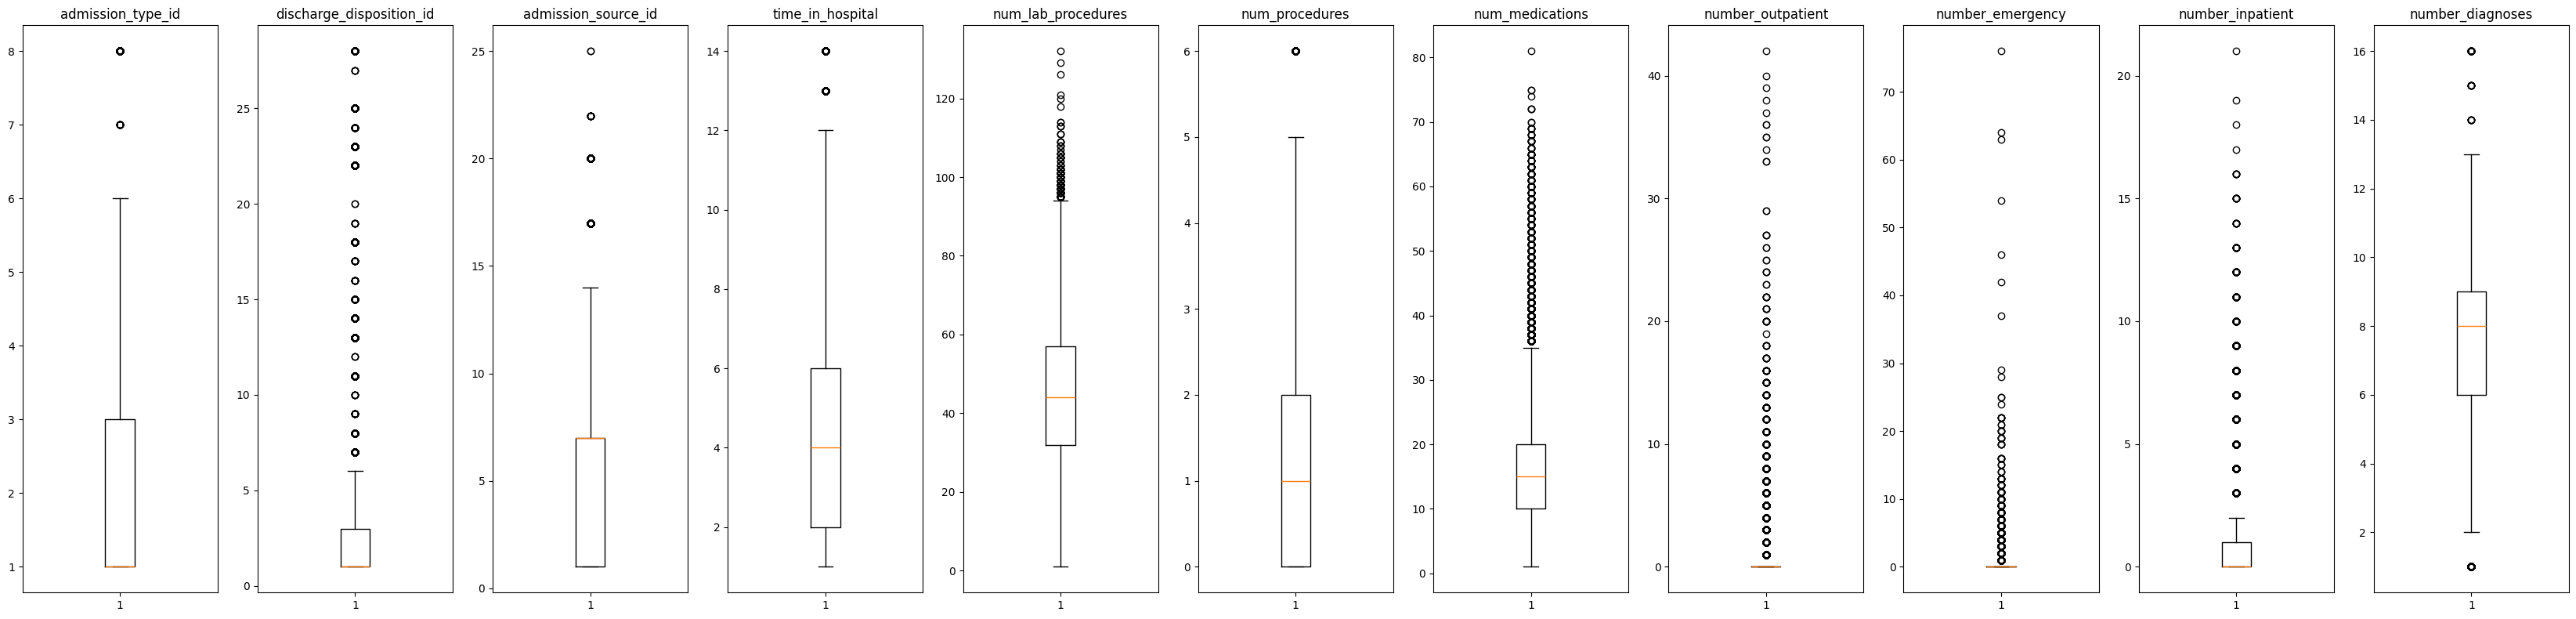

In [26]:
cols = numerical_features.columns
n = len(cols)

fig, axes = plt.subplots(1, n, figsize=(3*n, 8))

for i, col in enumerate(cols):
    axes[i].boxplot(numerical_features[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Correlation between features and target

In [27]:
#  multicollinearity test, check for skews in data distribution
#  across different features, run the heatmaps, ... and then start training models.

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_7 = df_6.copy()

# sample a small portion of the dataset for VIF
df_7 = df_7.sample(n=5000, random_state=1234)

# Drop columns that shouldn't be in VIF
df_7 = df_7.drop(columns=[
        'Unnamed: 0',
        'encounter_id',
        'patient_nbr',
        'readmitted'
    ])

bool_cols = df_7.select_dtypes(include='bool').columns
df_7[bool_cols] = df_7[bool_cols].astype(int)

df_7_np = df_7.to_numpy(dtype=float)

In [29]:
vif_data = pd.DataFrame({
    'feature': df_7.columns,
    'VIF': [variance_inflation_factor(df_7_np, i) for i in range(df_7_np.shape[1])]
})

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [30]:
print(vif_data.to_string())

                                             feature          VIF
0                                             gender     2.316259
1                                                age    24.300922
2                                  admission_type_id     4.055729
3                           discharge_disposition_id     1.671491
4                                admission_source_id     4.025818
5                                   time_in_hospital     5.119207
6                                 num_lab_procedures     8.060339
7                                     num_procedures     2.473590
8                                    num_medications     9.225092
9                                  number_outpatient     1.154339
10                                  number_emergency     1.129382
11                                  number_inpatient     1.452857
12                                  number_diagnoses    22.276982
13                                     max_glu_serum     1.498136
14        

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [49]:
X = df_6.copy()
y = X['readmitted'].copy()
X.drop('readmitted', axis=1, inplace=True)

In [50]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=1234, shuffle=True, test_size=.2)

# Logistic Regression

Basline Logistic model

In [34]:
model = LogisticRegression(random_state=1234)
model.fit(X_train, y_train)
predictions = model.predict(X_val)
accuracy = accuracy_score(y_val, predictions)
print("accuracy: ", accuracy, " error: ", (1-accuracy))

accuracy:  0.5392510099355825  error:  0.4607489900644175


Apply the standard scaler on the data

In [35]:
st_x = StandardScaler()
X_train_scaled = st_x.fit_transform(X_train)
X_val_scaled = st_x.transform(X_val)

model = LogisticRegression(random_state=1234)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, predictions)
print("accuracy: ", accuracy, " error: ", (1-accuracy))

accuracy:  0.5812315754995087  error:  0.41876842450049134


In [36]:
model = LogisticRegression(random_state=1234)
model.fit(X_train, y_train)
predictions = model.predict(X_val)
accuracy = accuracy_score(y_val, predictions)

print("accuracy: ", accuracy, " error: ", (1-accuracy))

accuracy:  0.5392510099355825  error:  0.4607489900644175


Train a non linear model on each of the non numeric features to see if it helps

In [37]:
import imblearn
from sklearn.preprocessing import PolynomialFeatures

def non_linear_logistic_regression():
    # get the numeric columns
    numeric_cols = []

    for col in X.columns:
        if X[col].nunique() > 2 and col not in ['readmitted', 'encounter_id', 'patient_nbr']:
            numeric_cols.append(col)

    results = []

    for col in numeric_cols:
        X_col = X[[col]].values
        y_target = y.values

        # train/test split
        X_train, X_test, y_train, y_test = train_test_split(X_col, y_target, test_size=0.2, random_state=1234)

        st_x = StandardScaler()
        X_train = st_x.fit_transform(X_train)
        X_test = st_x.transform(X_test)

        # linear model
        model_linear = LogisticRegression(random_state=1234)
        model_linear.fit(X_train, y_train)
        pred_linear = model_linear.predict(X_test)
        accuracy_linear = accuracy_score(y_test, pred_linear)

        # polynomial model
        poly = PolynomialFeatures(degree=12, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_poly = LogisticRegression(random_state=1234)
        model_poly.fit(X_train_poly, y_train)
        pred_poly = model_poly.predict(X_test_poly)
        accuracy_poly = accuracy_score(y_test, pred_poly)

        results.append((col, accuracy_linear, accuracy_poly))

    # sort by improvement
    for r in results:
        print(r)

Balancing the targets

before balance: 


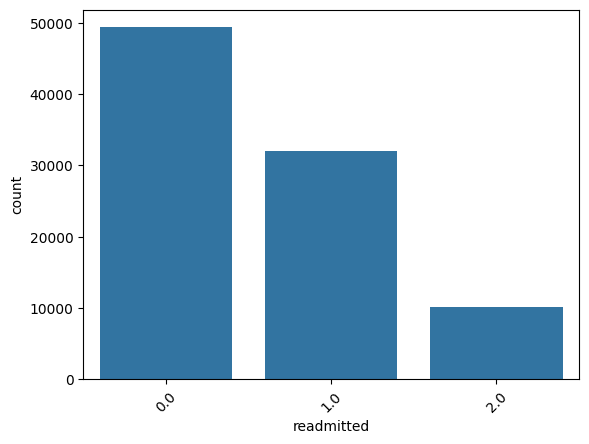

after balance


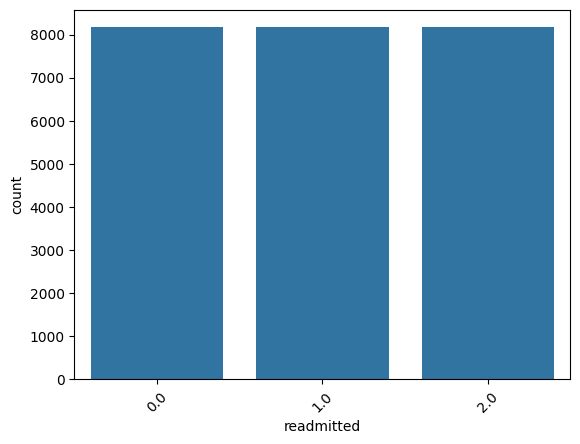

accuracy:  0.49830767551042693  error:  0.501692324489573


In [38]:
from imblearn.under_sampling import RandomUnderSampler

print("before balance: ")
sns.countplot(x='readmitted', data=df_6)
plt.xticks(rotation=45)
plt.show()

print("after balance")
undersample = RandomUnderSampler(random_state=1234)
X_over, y_over = undersample.fit_resample(X_train, y_train)

sns.countplot(x=y_over, data=df)
plt.xticks(rotation=45)
plt.show()

# train model on balanced results
st_x = StandardScaler()
X_train_scaled = st_x.fit_transform(X_over)
X_val_scaled = st_x.transform(X_val)

model = LogisticRegression(random_state=1234)
model.fit(X_train_scaled, y_over)
predictions = model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, predictions)

print("accuracy: ", accuracy, " error: ", (1-accuracy))

Choosing solvers

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/_newton_solver.py:576: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Ill-conditioned matrix (rcond=5.45439e-22): result may not be accurate.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/

([0, 1, 2, 3, 4],
 [Text(0, 0, 'newton-cholesky'),
  Text(1, 0, 'newton-cg'),
  Text(2, 0, 'lbfgs'),
  Text(3, 0, 'sag'),
  Text(4, 0, 'saga')])

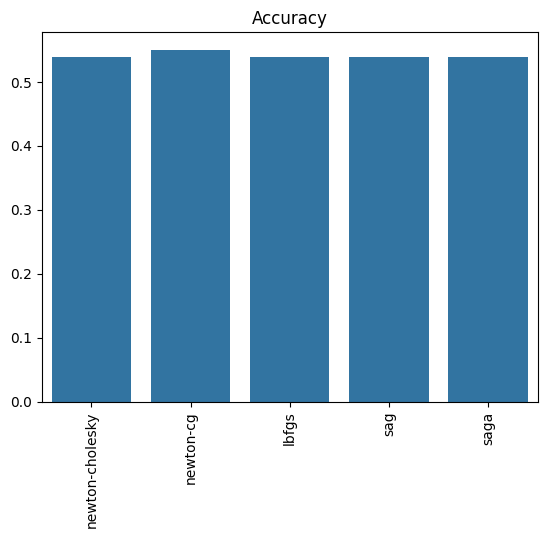

In [40]:
solver_list = ['newton-cholesky', 'newton-cg', 'lbfgs', 'sag', 'saga']
scores = []
params = []

for slvr in solver_list:
    try:
        model = LogisticRegression(random_state=1234, solver=slvr)
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        params.append(slvr)
        accuracy = accuracy_score(y_val, predictions)
        scores.append(accuracy)
    except:
        None

sns.barplot(x=params, y=scores).set_title('Accuracy')
plt.xticks(rotation=90)

In [46]:
st_x = StandardScaler()
X_train_scaled = st_x.fit_transform(X_train)
X_val_scaled = st_x.transform(X_val)

model = LogisticRegression(random_state=1234, solver='newton-cg')
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, predictions)

print("accuracy: ", accuracy, " error: ", (1-accuracy))

accuracy:  0.5810678021618081  error:  0.4189321978381919


Sequential Feature Selection

In [51]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline


model = LogisticRegression(random_state=1234)

# Sequential feature selector
sfs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=20,
    direction="forward",
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

# Put scaling + feature selection + model in one pipeline
pipe = Pipeline([
    ("feature_selection", sfs),
    ("model", model)
])

X_train_scaled = st_x.fit_transform(X_train)
X_val_scaled = st_x.transform(X_val)

# Fit only on training data
pipe.fit(X_train_scaled, y_train)

# Evaluate on held-out test set
test_score = pipe.score(X_val_scaled, y_val)
print("Test score:", test_score)

Test score: 0.5684026640462932
